# CHAZ visualizations

### Necessary packages

In [45]:
import numpy as np
import pandas as pd
#import cProfile
#import time

import xarray as xr


from datetime import datetime

import netCDF4 as nc

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import cartopy as cart
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import Namelist as gv

from scipy.stats import gaussian_kde


import glob

import os, re


### TEMPORARY (hopefully) code snippet so that the HTML view of datasets/dataarrays is viewable in darkmode on jupyter lab/VS code
from IPython.display import HTML, display

display(HTML("""
<style>
    .xr-wrap {
        --xr-background-color-row-odd: rgba(100, 100, 100, 0.10) !important;
        --xr-background-color-row-even: rgba(30, 30, 30, 0.10) !important;
    }
</style>
"""))

### Load in CHAZ ouput

In [2]:
filenames = sorted(glob.glob(gv.output_path + '/ERA5_*_ens*.nc'))

def preprocess(ds):
    yr = int(ds['year'].values[0])
    fname = os.path.basename(ds.encoding['source'])
    ens = int(re.search(r'ens(\d+)', fname).group(1))
    return ds.expand_dims(year_dim=[yr], ens=[ens])

ds = xr.open_mfdataset(
    filenames,
    preprocess=preprocess,
    combine="by_coords",   # was "nested"; it uses year_dim and ens coords to place each file
).load()

In [ ]:
ds

<xarray.Dataset> Size: 90MB
Dimensions:      (year_dim: 5, ens: 3, lifelength: 125, stormID: 140,
                  ensembleNum: 40)
Coordinates:
  * year_dim     (year_dim) int64 40B 2020 2021 2022 2023 2024
  * ens          (ens) int64 24B 0 1 2
  * lifelength   (lifelength) int64 1kB 0 1 2 3 4 5 ... 119 120 121 122 123 124
  * stormID      (stormID) int64 1kB 0 1 2 3 4 5 6 ... 134 135 136 137 138 139
  * ensembleNum  (ensembleNum) int64 320B 0 1 2 3 4 5 6 ... 33 34 35 36 37 38 39
Data variables:
    longitude    (year_dim, ens, lifelength, stormID) float64 2MB 145.8 ... nan
    latitude     (year_dim, ens, lifelength, stormID) float64 2MB -13.77 ... nan
    Mwspd        (year_dim, ens, ensembleNum, lifelength, stormID) float64 84MB ...
    year         (year_dim, ens, stormID) float64 17kB 2.02e+03 2.02e+03 ... nan
    time         (year_dim, ens, lifelength, stormID) datetime64[ns] 2MB 2020...

### Track Intensity

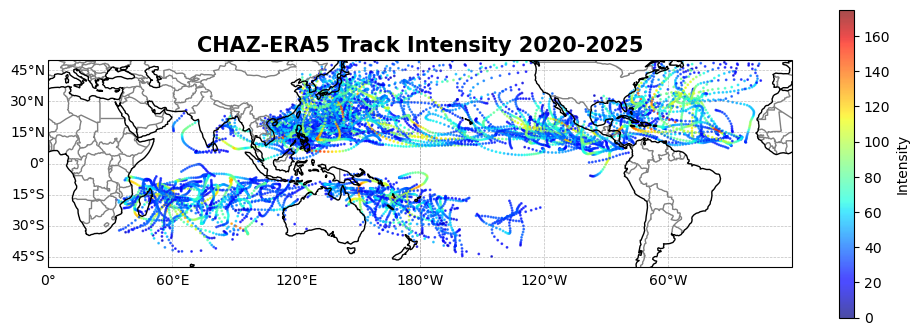

In [61]:
fig = plt.figure(figsize=(12,5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.coastlines(zorder=100)

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Use 0-360 or -180-180 values; with crs=PlateCarree() these are true longitudes
gl.xlocator = mticker.FixedLocator(list(range(-180, 181, 60)))
gl.ylocator = mticker.FixedLocator(range(-90, 91, 15))
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

ax.add_feature(cart.feature.BORDERS, color='gray')

# Extent must be given in the PlateCarree (unshifted) crs
ax.set_extent([0, 360, -50, 50], crs=ccrs.PlateCarree())

for iy in range(len(years)):
    filename = gv.output_path + '/ERA5_' + years[iy] + '_ens000.nc'
    data = nc.Dataset(filename)
    lon = data['longitude'][:]
    lat = data['latitude'][:]
    mwspd = data['Mwspd'][:]
    sc = ax.scatter(lon.ravel(), lat.ravel(), s=1,
                    c=mwspd[iN,:,:].ravel(),
                    cmap='jet',
                    vmin=0, vmax=175,
                    alpha=0.7,
                    transform=ccrs.PlateCarree())   # <-- important

plt.colorbar(sc, ax=ax, label='Intensity', shrink=0.8)
plt.title(f'CHAZ-ERA5 Track Intensity {gv.Year1}-{gv.Year2}',
          fontweight='bold', fontsize=15)
plt.savefig(f'figs/CHAZ_storm_tracks_ERA5_{gv.Year1}-{gv.Year2}.png', dpi=200)

### LMI (Lifetime Maximum Intensity)

In [58]:

def _get_basin_mask(latitude, longitude, basin):
    """
    Determine which storms have at least one track point inside a selected ocean basin.

    latitude, longitude:
        xarray.DataArray with dimensions (lifelength, stormID)

    Returns:
        1-D boolean numpy array with length stormID
    """

    if basin == 'ATL':
        # ~100°W–20°E, 0–60°N
        point_mask = (
            (latitude >= 0) &
            (latitude <= 60) &
            (
                (longitude >= 260) |
                (longitude <= 20)
            )
        )

    elif basin == 'WNP':
        # ~100°E–180°E, 0–50°N
        point_mask = (
            (latitude >= 0) &
            (latitude <= 50) &
            (longitude >= 100) &
            (longitude <= 180)
        )

    elif basin == 'GLOBAL':
        # 0–360°, -60–60°
        point_mask = (
            (latitude >= -60) &
            (latitude <= 60)
        )

    else:
        raise ValueError(
            f"Unknown basin: {basin}. "
            "Choose from 'ATL', 'WNP', or 'GLOBAL'."
        )

    
    ## A storm counts as 'in the ocean basin' if ANY part of its track is within the basin.
    storm_mask = point_mask.any(dim='lifelength')
    return storm_mask          # was: storm_mask.values


def get_vmax(ds, basin_key):
    vmax_all = []

    for i in ds.ens.values:
        ds_i = ds.sel(ens=i)

        # mask dims: (year_dim, stormID)
        basin_mask = _get_basin_mask(ds_i.latitude, ds_i.longitude, basin_key)

        # vmax dims: (year_dim, ensembleNum, stormID)
        vmax = ds_i.Mwspd.max(dim='lifelength', skipna=True)

        # mask broadcasts over ensembleNum by name
        vmax = vmax.where(basin_mask)

        vmax = vmax.values.ravel()
        vmax = vmax[~np.isnan(vmax)]

        vmax_all.append(vmax)

    if not vmax_all:
        raise ValueError("No valid data found.")

    vmax_concat = np.concatenate(vmax_all)
    return vmax_concat
    

def plot_LMI(ds, basin_key, bin_width=5):
    fig, ax = plt.subplots(figsize=(7, 5))

    vmax = get_vmax(ds, basin_key)
    vmax = vmax[np.isfinite(vmax)]

    x_min, x_max = 25, 200
    x_grid = np.linspace(x_min, x_max, 500)
    kde = gaussian_kde(vmax)

    ## histogram (density=True to match KDE's y-scale)
    bins = np.arange(x_min, x_max + bin_width, bin_width)
    ax.hist(
        vmax,
        bins=bins,
        density=True,
        color='lightgray',
        edgecolor='white',
        zorder=1,
    )

    ## kde
    ax.plot(
        x_grid,
        kde(x_grid),
        linewidth=2,
        color='C0',
        #label=f'KDE (n={len(vmax)})',
        zorder=2,
    )

    vmax = get_vmax(ds, basin_key)

    # Remove NaNs/infinite values
    vmax = vmax[np.isfinite(vmax)]

    # Kernel density estimate
    kde = gaussian_kde(vmax)


    x_grid = np.linspace(25, 200, 500)

    pdf = kde(x_grid)

    ax.plot(
        x_grid,
        pdf,
        linewidth=2,
    )

    ax.set_xlabel('Max Wind Speed (m/s)')
    ax.set_ylabel('Probability Density')

    ax.legend()
    ax.grid(alpha=0.25)

    plt.tight_layout()

    plt.title(f'Lifetime Maximum Intensity - {basin_key}')

    plt.show()

    return vmax

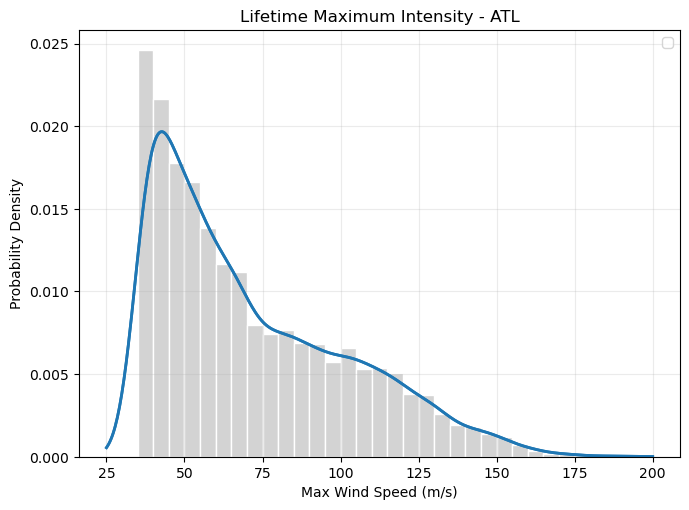

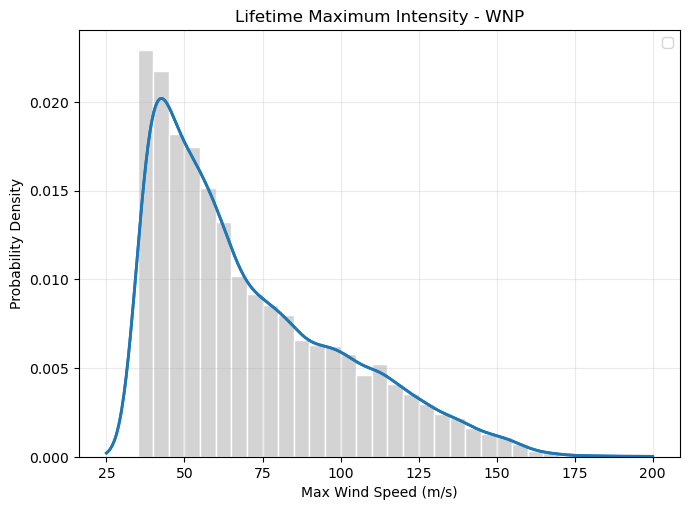

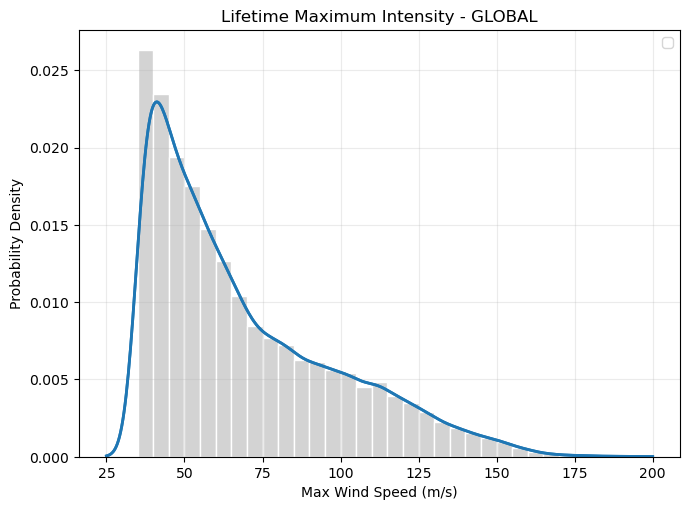

array([60.81530663, 68.727814  , 88.40041728, ..., 35.96692031,
       73.86235169, 47.6167379 ], shape=(49672,))

In [59]:
plot_LMI(ds, 'ATL')
plot_LMI(ds, 'WNP')
plot_LMI(ds, 'GLOBAL')

### Return Periods



### Track Density

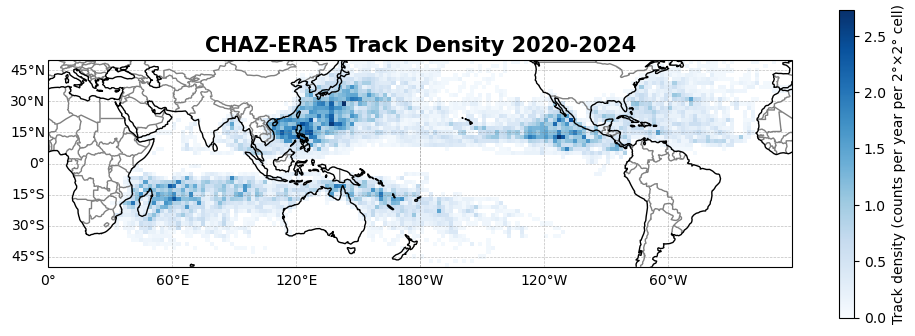

In [ ]:
def track_density(ds, min_wind_knots=34.0, member=0,
                  dlon=2.0, dlat=2.0,
                  lon_range=(0, 360), lat_range=(-60, 70)):
    """
    Track density (points per year per grid cell) from a single dataset.
    Effective years = len(year_dim) * len(ens).
    """
    wspd = ds["Mwspd"].isel(ensembleNum=member)          # (year_dim, ens, lifelength, stormID)
    lon  = ds["longitude"]
    lat  = ds["latitude"]

    # Align dims, then build mask and flatten
    wspd, lon, lat = xr.broadcast(wspd, lon, lat)
    lon = np.mod(lon, 360.0)                              # 0-360E (NaN stays NaN)

    mask = (wspd >= min_wind_knots) & lon.notnull() & lat.notnull()

    lon_pts = lon.values[mask.values]
    lat_pts = lat.values[mask.values]

    nyears_eff = ds.sizes["year_dim"] * ds.sizes["ens"]

    lon_edges = np.arange(lon_range[0], lon_range[1] + dlon, dlon)
    lat_edges = np.arange(lat_range[0], lat_range[1] + dlat, dlat)

    H, _, _ = np.histogram2d(lon_pts, lat_pts, bins=[lon_edges, lat_edges])
    density = H.T / nyears_eff                            # [lat, lon]

    return density, lon_edges, lat_edges, nyears_eff

def plot_track_density(density, lon_edges, lat_edges, title="",
                       cmap="Blues", vmin=0, vmax=None, savepath=None):
    lon2d, lat2d = np.meshgrid(lon_edges, lat_edges)

    fig = plt.figure(figsize=(12, 5))
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
    ax.coastlines(zorder=100)

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator(list(range(-180, 181, 60)))
    gl.ylocator = mticker.FixedLocator(range(-90, 91, 15))
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    ax.add_feature(cfeature.BORDERS, color='gray')

    # Extent in unshifted PlateCarree coordinates
    ax.set_extent([0, 360, -50, 50], crs=ccrs.PlateCarree())

    # Zeros -> transparent
    dens = np.where(density > 0, density, np.nan)
    cm = plt.get_cmap(cmap).copy()
    cm.set_bad((1, 1, 1, 0))

    pm = ax.pcolormesh(lon2d, lat2d, dens,
                       transform=ccrs.PlateCarree(),
                       cmap=cm, vmin=vmin, vmax=vmax)

    plt.colorbar(pm, ax=ax, label='Track density (counts per year per 2°×2° cell)',
                 shrink=0.8)
    plt.title(title, fontweight='bold', fontsize=15)

    if savepath:
        plt.savefig(savepath, dpi=200)
    return fig, ax


# ---- usage ----
density, lon_edges, lat_edges, n = track_density(ds, min_wind_knots=34)
plot_track_density(density, lon_edges, lat_edges,
                   title=f'CHAZ-ERA5 Track Density {int(ds.year_dim[0])}-{int(ds.year_dim[-1])}',
                   #cmap='jet',   
                   cmap = 'Blues'
                   savepath='figs/CHAZ_track_density_ERA5.png')
plt.show()

### Preprocessing Outputs

Preprocessing creates 3 files:
- A*YYYY.nc
- Cov*YYYY.nc
- YYYY*_r1i1p1f1.nc